In [1]:
%%capture
# set up path to include parent directory
import sys
sys.path.append('../')

# Import everything from the data_utils library
from data_utils import *

# Load the talk data
talk_data = get_only_talks(load_data())

In [2]:
# Import libraries and setup matplotlib defaults
from matplotlib import pyplot as pl
import pandas as pd
import numpy as np
pl.style.use('bmh')
prop_cycle = pl.cycler(color=['#377eb8','#e41a1c','#4daf4a','#984ea3',
                              '#ff7f00','#ffff33','#a65628','#f781bf','#999999'])
pl.rcParams.update({
    'axes.prop_cycle': prop_cycle,
    'lines.linewidth': 2,
    'font.size': 18,
    'figure.figsize': [12, 8],
    'figure.subplot.left': 0.125,
    'figure.subplot.right': 0.95,
    'figure.subplot.bottom': 0.15})

In [3]:
rpm_str = 'references (per 1000 words)'

# Create new date groups for 2 and 5 years at a time
talk_data['2y'] = pd.to_datetime(
    talk_data['date'].dt.year//2*20000+10101, format='%Y%m%d', utc=True)
talk_data['5y'] = pd.to_datetime(
    talk_data['date'].dt.year//5*50000+20701, format='%Y%m%d', utc=True)

def text_search_plot(search, title_str, leg_loc=None, spacer=' ', group='year'):
    if 'top_user' not in search.keys():
        search.update({'top_user': 'true'})
    result = text_search(talk_data, search, group=group, spacer=spacer, quiet=True)/1000
    fig, ax = pl.subplots()
    result.plot(ax=ax, legend=False, title=title_str, ylabel=rpm_str, xlabel='year')
    pl.legend(result.columns, loc=leg_loc)
    #pl.grid(axis='x')
    #ax.set_xlim(daterange)
    ax.set_ylim(bottom=0)

It's been observed that some general conference speakers don't mention Jesus much, and sometimes may even talk about or quote the current president of the church more. Those who don't believe Mormons are Christian accuse Mormons of elevating Joseph Smith to the same level as Jesus (or higher). (Certainly the somewhat hyperbolic phrase "more save Jesus only", written by John Taylor upon Joseph Smith's death and included in Doctrine and Covenants 135, probably contributes). At times there seems to be a lot of talk about Satan. So, who gets talked about the most in general conference? Has that changed over time?

## Names for Jesus
In order to get a handle on who is mentioned the most, we need to include all the various names people use to refer to Jesus. The following is a list of commonly used terms:
 - Jesus
 - Christ
 - Jesus Christ
 - (the) Savior
 - Redeemer
 - Master

There are a couple of complicating things to consider. Nearly every general conference talk ends with a reference to Jesus Christ, followed by an "amen". Also, there are a lot of references to the full name of the church. Neither of those really consitute talking about Jesus or his teachings in a significant way, so they have been filtered out for purposes of this analysis.

The plot below compares all of the various names. Three of the names have been relatively constant over time, one of them has experience a modest increase in the last decade ("Christ"), and two of them ("Jesus Christ" and "the Savior") have increased quite significantly over the last 5 years. In addition, use of the title "the Savior" was once the 4th most common term to use and it is now the 2nd most common.

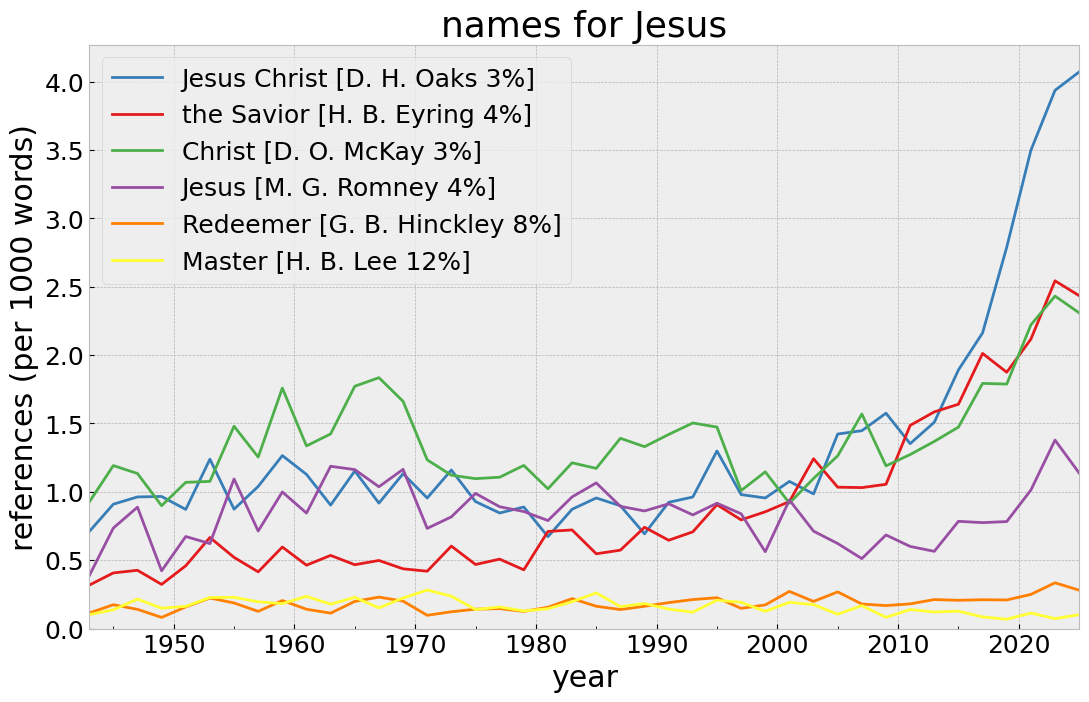

In [4]:
search_data_jesus = {
    "case sensitive": "true",
    #"include sum": "true",
    "search": [
        {"label": "Jesus Christ",
         "include": "Jesus Christ",
         "exclude": ["[Cc]hurch of Jesus Christ",
                     "Jesus Christ.{0,30}[Aa]men"]},
        {"label": "the Savior",
         "include": "[Tt]he Savior"},
        {"label": "Christ",
         "include": "(?<!Jesus )Christ",
         "exclude": ["Jesus is the Christ"]},
        {"label": "Jesus",
         "include": "Jesus(?! Christ)"},
        {"label": "Redeemer",
         "include": "Redeemer"},
        {"label": "Master",
         "include": "Master"}]}
text_search_plot(search_data_jesus, 'names for Jesus', group='2y', leg_loc='upper left')
result_j = text_search(talk_data, search_data_jesus, quiet=True)

Given the big surge in references to "Jesus Christ", it is worth examining the contexts in which it comes up most frequently to see what is driving the trend. Note that while the phrase "church of Jesus Christ" was exluded in the plot above, it is quite common, so it is included in this list for comparison. The most common phrases were the following:
 - gospel of Jesus Christ
 - Church of Jesus Christ
 - atonement of Jesus Christ
 - name of Jesus Christ (excluding final sentences of talks)
 - testament of Jesus Christ
 
It is notable that while both "testament" and "atonement" were low on the list in total volume, both of them experienced a significant surge in usage beginning in the 1980s. This coincides with the era when the Book of Mormon was published with a new subtitle: "Another Testament of Jesus Christ". Growth in references to atonement has been even larger, but starts slightly later.

The two most common contexts are references to "gospel" and "church". Both of these jumped significantly beginning in 2018 at the beginning of the presidency of Russell M. Nelson. The big increase in references to the full name of the church coincide exactly with President Nelson asking the church to do so, while it's unclear why references to "gospel" have increased in parallel.

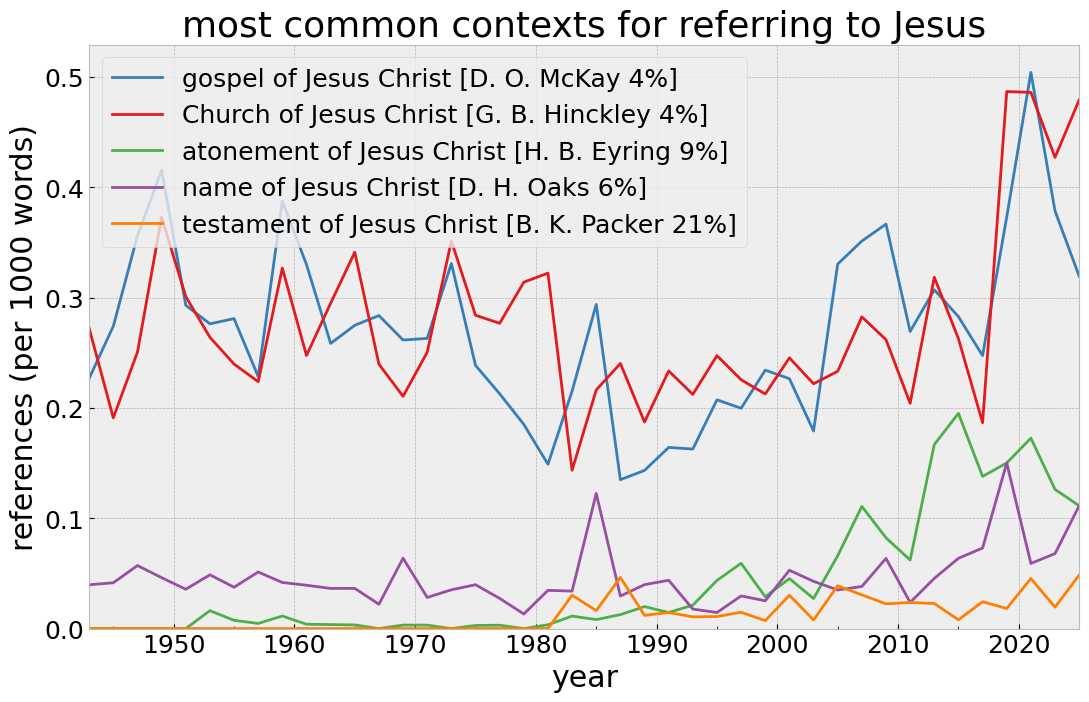

In [5]:
text_search_plot(
    {"search": [
        {"include": "gospel of jesus christ", "label": "gospel of Jesus Christ"},
        {"include": "church of jesus christ", "label": "Church of Jesus Christ"},
        {"include": "atonement of jesus christ", "label": "atonement of Jesus Christ"},
        {"include": "name of jesus christ", "label": "name of Jesus Christ",
         "exclude": ["name of jesus christ.{0,20}amen"]},
        {"include": "testament of jesus christ", "label": "testament of Jesus Christ"},
    ]}, 'most common contexts for referring to Jesus', group='2y', leg_loc='upper left')

## Satan
Just as Jesus has many names and titles, so does Satan. They are compared in the plot below.

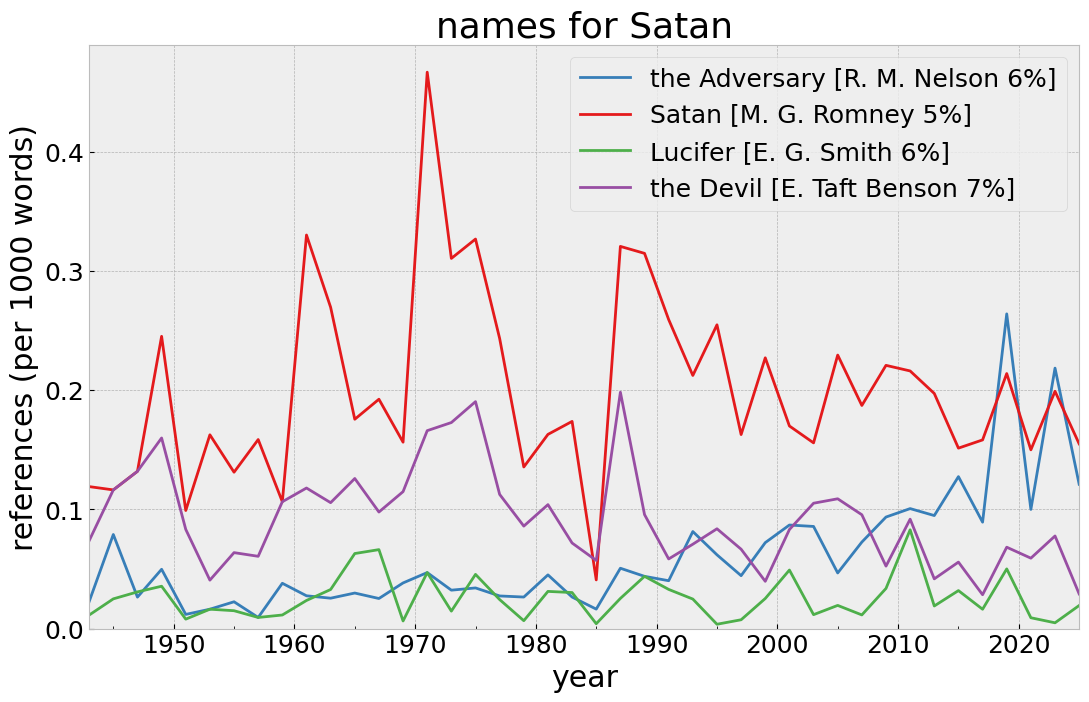

In [6]:
search_data_satan = {
    #"include sum": "true",
    "search": [
        {"label": "the Adversary", "include": "the adversary"},
        {"label": "Satan",   "include": "satan"},
        {"label": "Lucifer", "include": "lucifer"},
        {"label": "the Devil", "include": "the devil"}]}
text_search_plot(search_data_satan, 'names for Satan', group='2y', leg_loc='upper right')
result_s = text_search(talk_data, search_data_satan, quiet=True)

The most notable rhetorical shift that can be observed in this plot is a significant rise in popularity of the title "the Adversary", which runs almost exactly in parallel with the rise in the use of "the Savior" to refer to Jesus. Overall references to Satan in talks have been fairly stable for decades, but not particularly frequent overall.

In [7]:
# Get references to church presidents, and get total for current church president over tmie
apostle_data = load_apostle_data()
cur_apostles = apostle_data[apostle_data['dod'].isna()]['name'].values
president_list = apostle_data[~apostle_data['sdate_p'].isna()]['name']

pres_df = talk_data[['date', 'year', '2y', '5y', 'decade', 'author', 'president',
                     'word_count', 'rank', 'author_gender']].copy()
for pr in president_list.values:
    idx = talk_data['president']==pr
    lastname = pr.split(' ')[-1]
    if pr=='Joseph Smith':
        altstr = 'Prophet Joseph(?! Smith)'
    elif lastname=='Smith': # "President Smith" is ambiguous
        altstr = 'President Smith'
    else:
        altstr = 'President ' + lastname
    pres_df[pr] = talk_data['body'].str.count(pr) + \
                  talk_data['body'].str.count(altstr)
    pres_df.loc[idx, 'current'] = talk_data.loc[idx, 'body'].str.count(pr) + \
                                  talk_data.loc[idx, 'body'].str.count(altstr)

yearly_totals = pres_df.groupby('year')[['word_count', 'current']].sum()



jesus=result_j.sum(1)
satan=result_s.sum(1)
joseph_smith = text_search(talk_data, {"case sensitive": "true", "search": [{"include": "Joseph Smith"}]},
                           quiet=True)['Joseph Smith']
cur_pres_refs = yearly_totals['current']/yearly_totals['word_count']*1e6

compare_df = pd.concat({'Jesus':jesus, 'Satan':satan, 'Joseph Smith':joseph_smith,
                        'Current President':cur_pres_refs}, axis='columns')/1e3

## Joseph Smith and the president of the church

As mentioned in the introduction, it is also relevant to compare references to Joseph Smith and to the current president of the church. To properly count references, uses of the phrase "Prophet Joseph" were counted as Joseph Smith references, and references to "President Smith" refer to the president of the church when George Albert Smith and Joseph Fielding Smith were respectively presidents of the church.

The comparison of all of these collective references, along with Jesus and Satan references, are shown in the plot below.

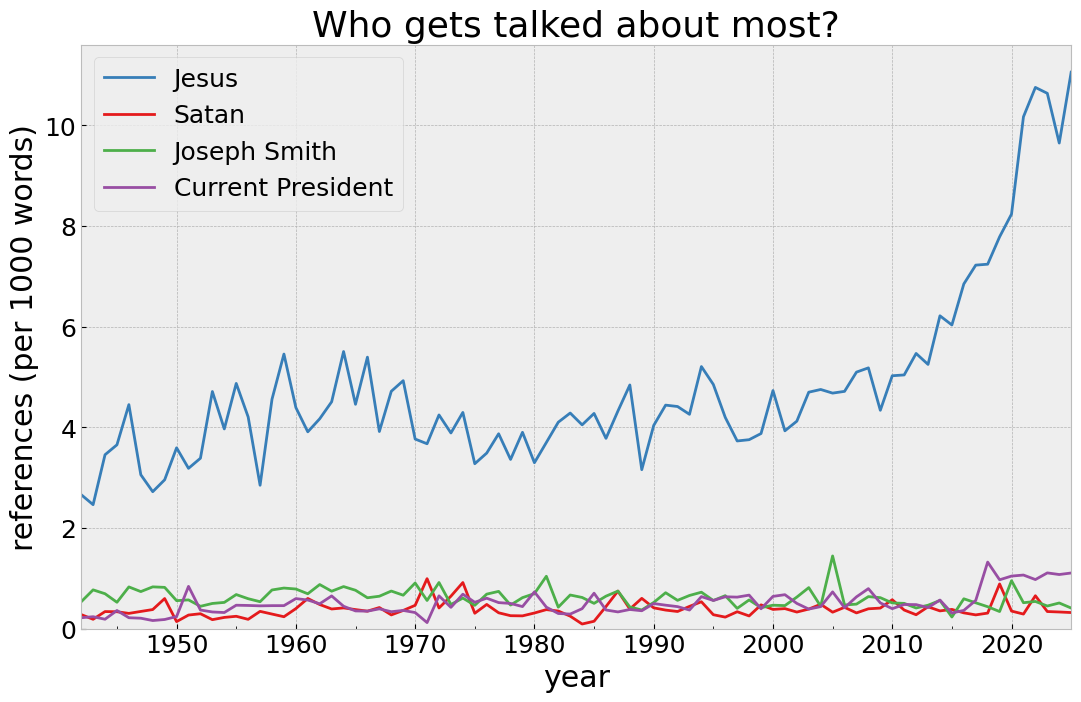

In [8]:
_ = compare_df.plot(title='Who gets talked about most?', ylim=[0, None], ylabel=rpm_str)

The plot reveals two significant insights:

* Contrary to some perceptions, Jesus has always been mentioned more than any of the others (Satan, Joseph Smith, or the current church president). There have always been individual talks that are notable exceptions to this, and those talks have likely colored perceptions on this question, but they tend to be outliers.
* The presidency of Russell M. Nelson (2018-2025) had a remarkable effect on two of the trends, with sudden parellel increases in references to both Jesus and to the president of the church.

The recent increase in church president references under Nelson has previously been analyzed in detail [here](https://qhspencer.github.io/lds-data-analysis/presidents/). I speculated then that the effect is so pronounced, and because Nelson was himself previously a prolific quoter of previous presidents, that it is likely something he personally believed to be an important aspect of the role of president of the church and may have encouraged speakers to do. As for the increase in references to Jesus, the cause would seem to be more obvious. During his tenure as president of the church, Nelson had explicitly expressed a desire to refocus the church on Christ, including overseeing efforts to redesign the church logo and promoting the use of the full name of the church in the context of trying to focus more on Christ. It would appear that these efforts clearly had an effect on general conference speakers. Time will tell how persistent this effect proves to be on speakers, and how it affects the culture of the church.

In [9]:
# Setup show/hide source code box
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()">
<input type="submit" value="show/hide source code"></form>''')